<a href="https://colab.research.google.com/github/BiswajitMallickCSE/Deep-Learning-Based-Automated-License-Plate-Detection-and-Recognition-System/blob/main/Deep_Learning_Based_Automated_License_Plate_Detection_and_Recognition_System_Using_YOLO_and_Multi_Engine_OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Install Required Libraries**


In [1]:
!pip -q install -U ultralytics easyocr pytesseract opencv-python matplotlib
!pip -q uninstall -y Pillow
!pip -q install --no-cache-dir --force-reinstall "Pillow==11.3.0"
!apt-get -qq update
!apt-get -qq install -y tesseract-ocr


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 157.5 MB/s eta 0:00:00
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.

##**Import Required Libraries**



In [2]:
import os
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import PIL
import easyocr
import pytesseract
from PIL import Image
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


##**Check Libraries and GPU Availability**


In [3]:
print("Pillow:", PIL.__version__)
print("Pillow path:", PIL.__file__)
print("Torch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
USE_GPU = torch.cuda.is_available()


Pillow: 11.3.0
Pillow path: /usr/local/lib/python3.13/dist-packages/PIL/__init__.py
Torch: 2.11.0+cu128
GPU available: True


##**Download and Load the YOLO License Plate Detection Model**


In [4]:
MODEL_URL = "https://huggingface.co/Koushim/yolov8-license-plate-detection/resolve/main/best.pt"
MODEL_PATH = "license_plate_best.pt"

if not os.path.exists(MODEL_PATH):
    !wget -q -O license_plate_best.pt "$MODEL_URL"
plate_model = YOLO(MODEL_PATH)


##**Initialize EasyOCR and Tesseract**


In [5]:
print("Loading EasyOCR...")
ocr_reader = easyocr.Reader(["en"], gpu=USE_GPU)
try:
    print("Tesseract:", pytesseract.get_tesseract_version())
except Exception as e:
    raise RuntimeError(f"Tesseract is not available: {e}")


Loading EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteTesseract: 5.3.4


##**Upload the Input Image**



In [6]:
from google.colab import files
uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No image was uploaded.")


Saving research_car.jpg to research_car.jpg


##**Read and Display the Input Image**



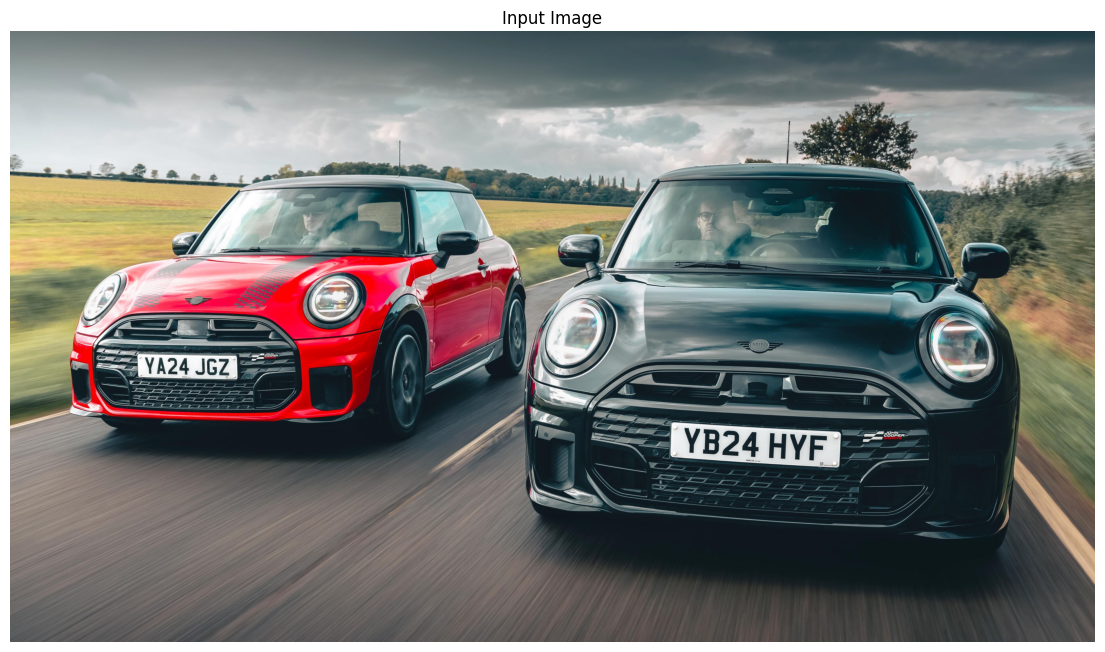

In [7]:
IMAGE_PATH = next(iter(uploaded.keys()))
image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    raise RuntimeError(f"Could not read image: {IMAGE_PATH}")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Input Image")
plt.show()


##**Define All-Plate YOLO Detection**

In [8]:
def detect_all_plates(img_bgr, conf=0.12, iou=0.45, imgsz=1280):
    results = plate_model.predict(
        source=img_bgr,
        imgsz=imgsz,
        conf=conf,
        iou=iou,
        max_det=100,
        verbose=False
    )
    detections = []
    H, W = img_bgr.shape[:2]
    image_area = H * W

    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
        boxes = result.boxes.xyxy.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        for box, score in zip(boxes, confs):
            x1, y1, x2, y2 = map(int, box)
            x1 = max(0, min(x1, W - 1))
            y1 = max(0, min(y1, H - 1))
            x2 = max(0, min(x2, W))
            y2 = max(0, min(y2, H))
            bw = x2 - x1
            bh = y2 - y1
            area = bw * bh

            # Ignore extremely tiny detections.
            if bw < 18 or bh < 6 or area < 150:
                continue

            # Ignore implausible plate shapes.
            aspect = bw / max(bh, 1)
            if aspect < 1.4 or aspect > 12.0:
                continue

            # Small detections need stronger confidence.
            if area < image_area * 0.00008 and float(score) < 0.25:
                continue

            detections.append({
                "box": (x1, y1, x2, y2),
                "conf": float(score),
                "area": area
            })

    # Sort left-to-right, then top-to-bottom.
    detections.sort(
        key=lambda d: (d["box"][1], d["box"][0])
    )

    return detections


##**Execute License Plate Detection**



In [9]:
all_detections = detect_all_plates(
    image_bgr,
    conf=0.12,
    iou=0.45,
    imgsz=1280
)
print(f"Detected {len(all_detections)} license plate(s).")
if not all_detections:
    raise RuntimeError(
        "No license plates detected. Try a clearer image or lower "
        "the detector confidence to 0.08."
    )


Detected 2 license plate(s).


##**Crop Every Detected License Plate**



In [10]:
# Create safe crops for EVERY detected plate.
plate_items = []

H, W = image_bgr.shape[:2]

for idx, det in enumerate(all_detections, start=1):

    x1, y1, x2, y2 = det["box"]

    bw = x2 - x1
    bh = y2 - y1

    pad_x = max(4, int(bw * 0.06))
    pad_y = max(3, int(bh * 0.12))

    cx1 = max(0, x1 - pad_x)
    cy1 = max(0, y1 - pad_y)
    cx2 = min(W, x2 + pad_x)
    cy2 = min(H, y2 + pad_y)

    crop = image_bgr[cy1:cy2, cx1:cx2].copy()

    plate_items.append({
        "id": idx,
        "box": (cx1, cy1, cx2, cy2),
        "detector_box": (x1, y1, x2, y2),
        "conf": det["conf"],
        "crop": crop
    })


##**Preview Detected Plate Crops**

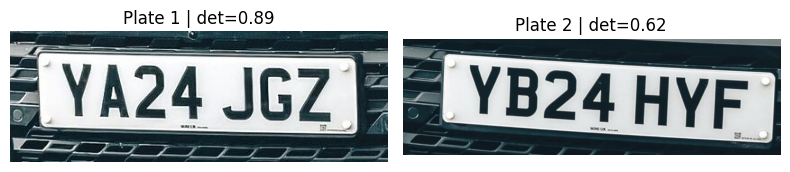

In [11]:
# Preview every detected plate crop.
cols = min(4, len(plate_items))
rows = int(np.ceil(len(plate_items) / cols))

plt.figure(figsize=(4 * cols, 3 * rows))

for i, item in enumerate(plate_items, start=1):
    ax = plt.subplot(rows, cols, i)
    ax.imshow(cv2.cvtColor(item["crop"], cv2.COLOR_BGR2RGB))
    ax.axis("off")
    ax.set_title(
        f"Plate {item['id']} | det={item['conf']:.2f}"
    )
plt.tight_layout()
plt.show()


##**Define License Plate Text Rules**




In [12]:
ALLOWED = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
USE_UK_FORMAT = True
UK_RE = re.compile(r"^[A-Z]{2}[0-9]{2}[A-Z]{3}$")
def clean_text(s):
    return re.sub(r"[^A-Z0-9]", "", str(s).upper())
def generate_candidates(raw):
    s = clean_text(raw)
    if not s:
        return []
    if not USE_UK_FORMAT:
        return [s]
    candidates = []

    if len(s) >= 7:
        for i in range(len(s) - 6):
            candidates.append(s[i:i+7])

    digit_map = {
        "O": "0", "Q": "0", "D": "0",
        "I": "1", "L": "1",
        "Z": "2", "S": "5",
        "G": "6", "T": "7", "B": "8"
    }
    letter_map = {
        "0": "O", "1": "I", "2": "Z",
        "5": "S", "6": "G", "7": "T", "8": "B"
    }
    expanded = list(candidates)
    for base in candidates:
        chars = list(base)

        for p in (2, 3):
            if chars[p] in digit_map:
                chars[p] = digit_map[chars[p]]

        for p in (0, 1, 4, 5, 6):
            if chars[p] in letter_map:
                chars[p] = letter_map[chars[p]]

        expanded.append("".join(chars))

    valid = []

    for c in expanded:
        if UK_RE.fullmatch(c):
            valid.append(c)

    return list(dict.fromkeys(valid))


##**Build Image Preprocessing Variants**


In [13]:
def make_variants(plate_bgr):
    gray = cv2.cvtColor(plate_bgr, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape[:2]

    mx = max(1, int(w * 0.015))
    my = max(1, int(h * 0.04))

    if w > 20 and h > 10 and w - 2 * mx > 10 and h - 2 * my > 5:
        gray = gray[my:h-my, mx:w-mx]

    up = cv2.resize(
        gray,
        None,
        fx=8,
        fy=8,
        interpolation=cv2.INTER_CUBIC
    )

    bilateral = cv2.bilateralFilter(up, 7, 45, 45)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    contrast = clahe.apply(bilateral)

    blur = cv2.GaussianBlur(contrast, (0, 0), 1.1)
    sharp = cv2.addWeighted(
        contrast, 1.6,
        blur, -0.6,
        0
    )

    otsu = cv2.threshold(
        sharp, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    adaptive = cv2.adaptiveThreshold(
        sharp,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        9
    )

    return {
        "gray": up,
        "contrast": contrast,
        "sharp": sharp,
        "otsu": otsu,
        "adaptive": adaptive
    }


##**Define the Multi-Engine OCR Function**


In [14]:
def ocr_one_plate(plate_bgr):
    variants = make_variants(plate_bgr)
    raw_results = []
    votes = {}
    def add(raw, engine, variant, confidence=0.0, weight=1.0):
        raw_clean = clean_text(raw)
        if not raw_clean:
            return
        raw_results.append({
            "engine": engine,
            "variant": variant,
            "raw": raw_clean,
            "confidence": float(confidence)
        })
        for candidate in generate_candidates(raw_clean):
            c = max(0.0, min(float(confidence), 1.0))
            score = weight * (1.0 + c)
            votes[candidate] = votes.get(candidate, 0.0) + score
    for name, im in variants.items():
        try:
            results = ocr_reader.readtext(
                im,
                detail=1,
                paragraph=False,
                allowlist=ALLOWED,
                decoder="beamsearch",
                beamWidth=10,
                text_threshold=0.35,
                low_text=0.15,
                link_threshold=0.15,
                mag_ratio=1.5
            )

            for item in results:
                if len(item) >= 3:
                    add(
                        item[1],
                        "EasyOCR-beam",
                        name,
                        item[2],
                        1.0
                    )
        except Exception as e:
            print("EasyOCR beam warning:", e)

        try:
            results = ocr_reader.readtext(
                im,
                detail=1,
                paragraph=False,
                allowlist=ALLOWED,
                decoder="greedy",
                beamWidth=5,
                text_threshold=0.25,
                low_text=0.10,
                link_threshold=0.10,
                mag_ratio=1.8
            )

            for item in results:
                if len(item) >= 3:
                    add(
                        item[1],
                        "EasyOCR-greedy",
                        name,
                        item[2],
                        0.9
                    )
        except Exception as e:
            print("EasyOCR greedy warning:", e)

    for name, im in variants.items():

        for psm in (6, 7, 8, 13):

            try:
                config = (
                    f"--psm {psm} "
                    "-c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 "
                    "-c preserve_interword_spaces=0"
                )

                text = pytesseract.image_to_string(
                    im,
                    config=config
                ).strip()

                if text:
                    add(
                        text,
                        f"Tesseract-PSM{psm}",
                        name,
                        0.90 if psm == 7 else 0.75,
                        1.45 if psm == 7 else 1.0
                    )

            except Exception as e:
                print("Tesseract warning:", e)

    if votes:
        ranked = sorted(
            votes.items(),
            key=lambda x: x[1],
            reverse=True
        )

        best = ranked[0][0]

        if USE_UK_FORMAT and len(best) == 7:
            final = best[:2] + best[2:4] + " " + best[4:]
        else:
            final = best

    else:
        ranked = []
        final = "UNREADABLE"

    return {
        "final": final,
        "raw_results": raw_results,
        "ranked": ranked
    }


##**OCR Every Detected Plate**


In [15]:
plate_results = []
print("================================================")
print(f"OCR STARTED FOR {len(plate_items)} DETECTED PLATE(S)")
print("================================================")
for item in plate_items:
    print(
        f"\n---------------- Plate {item['id']} "
        f"----------------"
    )
    result = ocr_one_plate(item["crop"])
    item["ocr"] = result
    plate_results.append(item)
    print("FINAL:", result["final"])
    print("Top candidates:")
    for cand, score in result["ranked"][:5]:
        if USE_UK_FORMAT and len(cand) == 7:
            display_cand = cand[:2] + cand[2:4] + " " + cand[4:]
        else:
            display_cand = cand

        print(
            f"  {display_cand}  score={score:.2f}"
        )

print("\n================================================")
print("OCR FINISHED FOR ALL DETECTED PLATES")
print("================================================")


OCR STARTED FOR 2 DETECTED PLATE(S)

---------------- Plate 1 ----------------
FINAL: YA24 JGZ
Top candidates:
  YA24 JGZ  score=10.74
  VA24 JGZ  score=7.00
  PA71 AAU  score=1.75
  TA41 PTE  score=1.75
  TA77 JOS  score=1.75

---------------- Plate 2 ----------------
FINAL: YB24 HYF
Top candidates:
  YB24 HYF  score=14.00
  UM48 SMY  score=1.75
  CO55 OTZ  score=1.75
  OS50 TZA  score=1.75
  SS07 ZAZ  score=1.75

OCR FINISHED FOR ALL DETECTED PLATES


##**Annotate the Original Image**


In [16]:
output = image_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX
occupied_labels = []
for item in plate_results:
    x1, y1, x2, y2 = item["box"]
    text = item["ocr"]["final"]
    cv2.rectangle(
        output,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        3
    )
    label = f"PLATE {item['id']}: {text}"

    scale = max(
        0.45,
        min(0.8, output.shape[1] / 1800)
    )
    thickness = 2

    (tw, th), baseline = cv2.getTextSize(
        label,
        font,
        scale,
        thickness
    )
    ly2 = max(th + 8, y1)
    ly1 = ly2 - th - 12

    if ly1 < 0:
        ly1 = y2 + 4
        ly2 = min(
            output.shape[0] - 1,
            ly1 + th + 12
        )
        text_y = min(
            output.shape[0] - 4,
            ly1 + th + 5
        )
    else:
        text_y = ly2 - 6

    lx1 = max(0, x1)
    lx2 = min(
        output.shape[1] - 1,
        lx1 + tw + 14
    )

    cv2.rectangle(
        output,
        (lx1, ly1),
        (lx2, ly2),
        (0, 255, 0),
        -1
    )

    cv2.putText(
        output,
        label,
        (lx1 + 7, text_y),
        font,
        scale,
        (0, 0, 0),
        thickness,
        cv2.LINE_AA
    )


##**Save the Final Result Image**


In [17]:
OUTPUT_PATH = "license_plate_multi_car_result.jpg"

cv2.imwrite(
    OUTPUT_PATH,
    cv2.cvtColor(output, cv2.COLOR_RGB2BGR)
)


True

##**Display the Final Multi-Plate OCR Result**


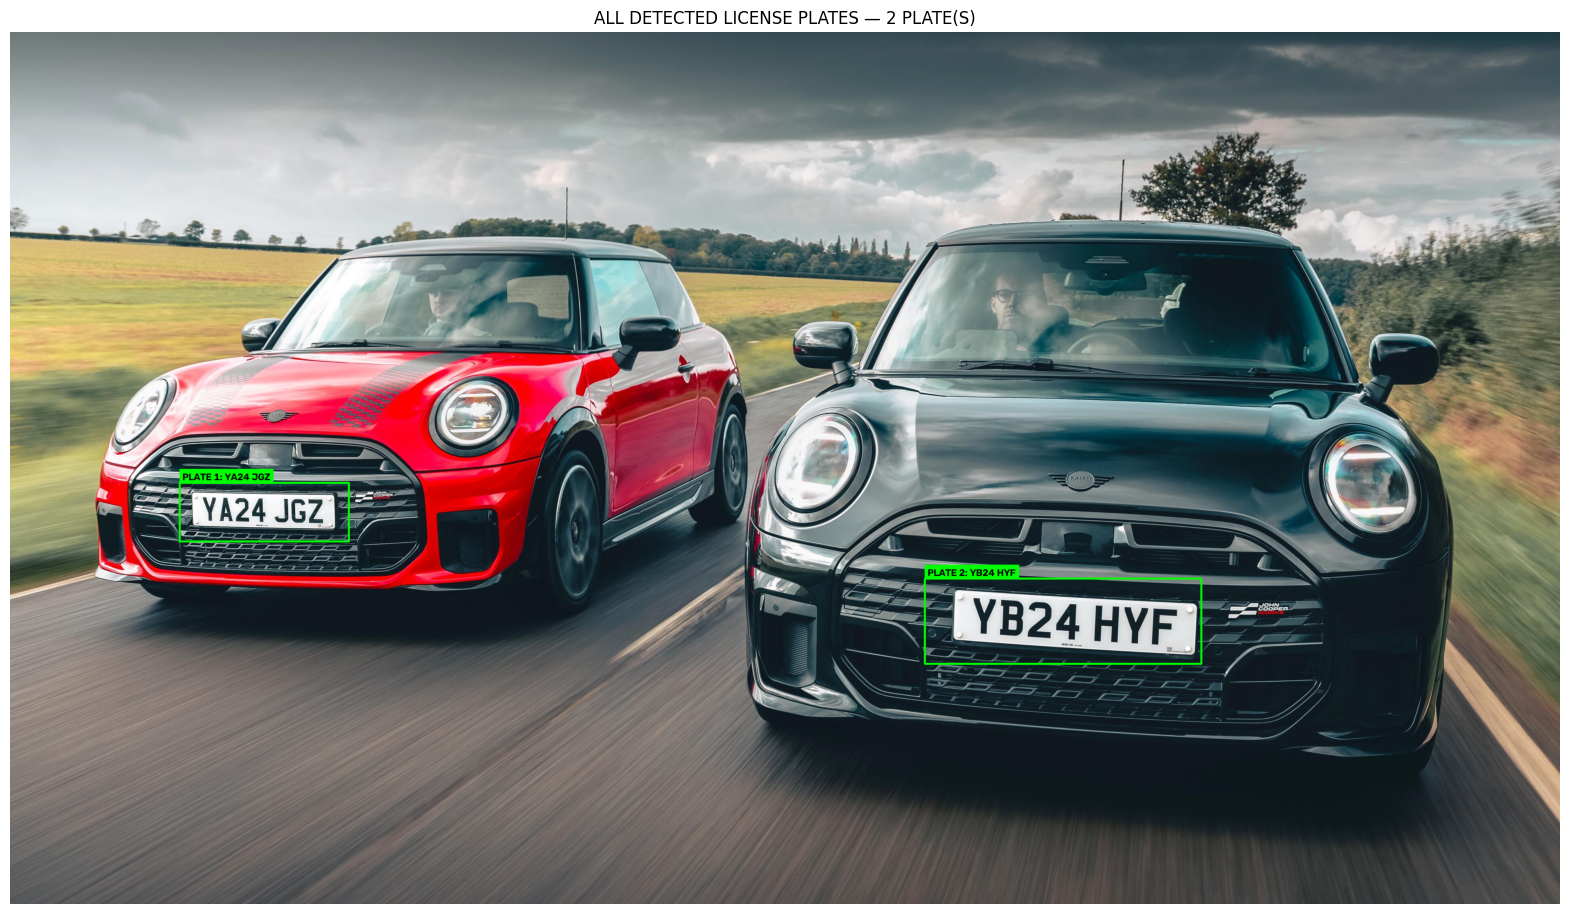

In [18]:
plt.figure(figsize=(20, 12))
plt.imshow(output)
plt.axis("off")
plt.title(
    f"ALL DETECTED LICENSE PLATES — {len(plate_results)} PLATE(S)"
)
plt.show()